In [1]:
import os
import pandas as pd
import numpy as np
import re
import utils
import matplotlib.pyplot as plt

In [2]:
# Make output folder
output_dir = os.path.join('..','..','..','phd_1_analysis','plots','modelling')
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

In [3]:
preprocessed_model_fit_folder = f'/Volumes/project/3025011.02/pre-processed/modelling/model_fit'
model_fit_pattern = re.compile(r'^model_fit_sub-\d{3}_session-\d{2}\.csv$')

## Which subjects and sessions do we want to include?

In [4]:
unique_subject_ids = [5, 10, 13, 14, 15, 16, 20, 22, 23, 25, 27, 28, 29, 30, 32, 37]#[5, 10, 14, 15, 16, 20, 22, 23, 25, 28, 29, 37] #
unique_sessions = [1]

In [5]:
model_fit_combined = []
# Iterate through files in the folder
for file_name in os.listdir(preprocessed_model_fit_folder):
    if model_fit_pattern.match(file_name):
        path = os.path.join(preprocessed_model_fit_folder, file_name)
        model_fit = pd.read_csv(path, sep=';')
        model_fit_combined.append(model_fit)

model_fit_combined = pd.concat(model_fit_combined, ignore_index=True)
model_fit_combined = model_fit_combined.sort_values(by=['subject', 'session'])
print(model_fit_combined)

    subject  session  trials   model0_ll  model0_q_happy_pull  \
7         5        1     646 -433.348327             0.275887   
3         5        2     656 -453.861715            -0.239330   
2         5        3     655 -451.260352             0.110722   
5         5        4     660 -453.183480             0.176909   
4        10        1     658 -454.762216            -0.577491   
1        10        2     655 -451.443903            -0.126085   
0        10        3     658 -456.060504            -0.367114   
9        10        4     654 -453.131677            -0.371558   
8        13        1     629 -432.921191            -0.459725   
6        13        2     378 -260.599975            -0.663515   
10       14        1     648 -447.990521             0.582061   
15       14        2     658 -455.494915             0.783772   
11       14        3     656 -451.129295             0.739635   
16       14        4     655 -453.948784             0.169713   
18       15        1     

In [6]:
## Only keep the rows with subjects and sessions we want
model_fit_combined = model_fit_combined[
    model_fit_combined['subject'].isin(unique_subject_ids) &
    model_fit_combined['session'].isin(unique_sessions)
]

In [7]:
# Automatically detect models
models = [col.split('_')[0] for col in model_fit_combined.columns if '_ll' in col]
models = sorted(set(models))

In [8]:
# Initialize dictionaries for AIC/BIC
for model in models:
    # Count the number of parameters per model
    param_cols = [col for col in model_fit_combined.columns if col.startswith(model + '_') and col != model + '_ll']
    k = len(param_cols)

    # Get negative log-likelihoods
    ll = model_fit_combined[f'{model}_ll']
    #ll = -neg_ll  # Convert to positive log-likelihood

    # Calculate AIC and BIC
    model_fit_combined[f'{model}_AIC'] = 2 * k - 2 * ll
    model_fit_combined[f'{model}_BIC'] = k * np.log(model_fit_combined['trials']) - 2 * ll

print(model_fit_combined)

    subject  session  trials   model0_ll  model0_q_happy_pull  \
7         5        1     646 -433.348327             0.275887   
4        10        1     658 -454.762216            -0.577491   
8        13        1     629 -432.921191            -0.459725   
10       14        1     648 -447.990521             0.582061   
18       15        1     658 -455.832419             0.058720   
17       16        1     646 -435.258316             0.490192   
21       20        1     649 -442.557903            -0.496470   
25       22        1     650 -448.521785             0.488354   
26       23        1     649 -443.911676             0.176643   
33       25        1     657 -440.610082            -0.254193   
36       27        1     652 -445.914774            -0.340361   
43       28        1     644 -445.981661             0.499965   
40       29        1     646 -428.537911             0.292606   
47       30        1     652 -439.515691             0.417354   
46       32        1     

In [9]:
# Fixed effects group comparison for AIC and BIC
# Take columns that contain AIC or BIC
aic_bic_cols = [col for col in model_fit_combined.columns if 'AIC' in col or 'll' in col]

# Build the total row as a dict comprehension
total_row = {
    col: model_fit_combined[col].sum()   if col in aic_bic_cols
         else 0
    for col in model_fit_combined.columns
}

# Overwrite the session/subject entries
total_row['subject'] = 'total'
total_row['session'] = 'total'

# Add the total row to the DataFrame
total_df = pd.DataFrame([total_row])
model_fit_combined = pd.concat([model_fit_combined, total_df], ignore_index=True)
print(model_fit_combined)

   subject session  trials    model0_ll  model0_q_happy_pull  \
0        5       1     646  -433.348327             0.275887   
1       10       1     658  -454.762216            -0.577491   
2       13       1     629  -432.921191            -0.459725   
3       14       1     648  -447.990521             0.582061   
4       15       1     658  -455.832419             0.058720   
5       16       1     646  -435.258316             0.490192   
6       20       1     649  -442.557903            -0.496470   
7       22       1     650  -448.521785             0.488354   
8       23       1     649  -443.911676             0.176643   
9       25       1     657  -440.610082            -0.254193   
10      27       1     652  -445.914774            -0.340361   
11      28       1     644  -445.981661             0.499965   
12      29       1     646  -428.537911             0.292606   
13      30       1     652  -439.515691             0.417354   
14      32       1     620  -424.707711 

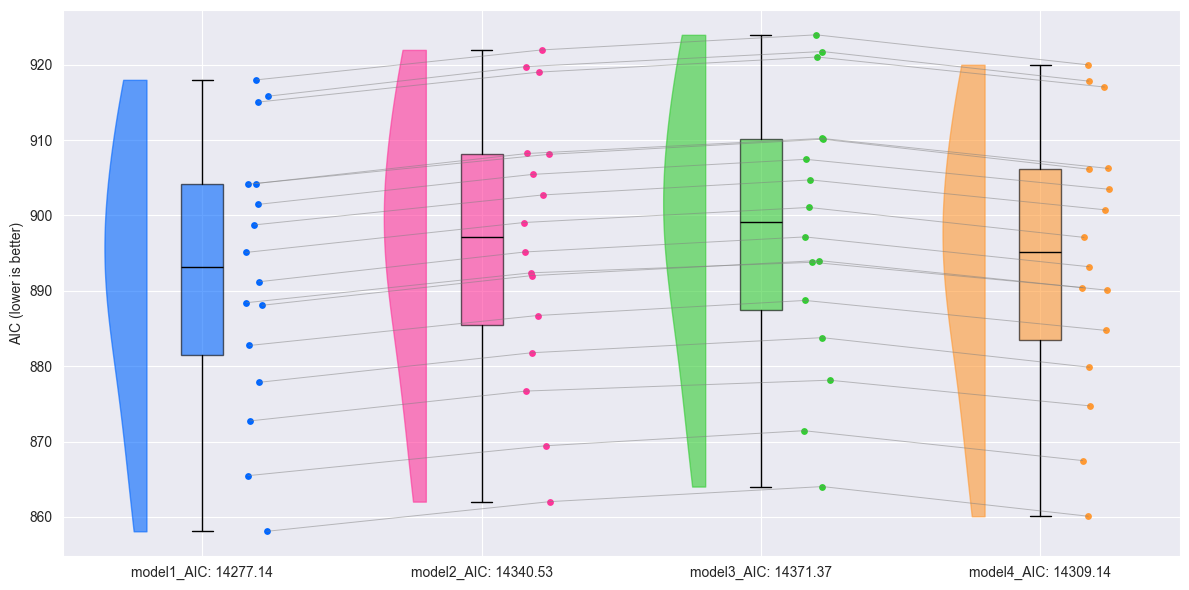

In [10]:
# Remove total column
model_fit_plot = model_fit_combined[model_fit_combined['subject'] != 'total']
model_fit_total = model_fit_combined[model_fit_combined['subject'] == 'total']

# Plot the two groups using a raincloud plot
utils.plotting_functions.paired_raincloud_4_groups(
    model_fit_plot,
    columns=['model1_AIC', 'model2_AIC', 'model3_AIC', 'model4_AIC'],
    labels=[f'model1_AIC: {model_fit_total["model1_AIC"].iloc[0]:.2f}', f'model2_AIC: {model_fit_total["model2_AIC"].iloc[0]:.2f}', f'model3_AIC: {model_fit_total["model3_AIC"].iloc[0]:.2f}', f'model4_AIC: {model_fit_total["model4_AIC"].iloc[0]:.2f}'],
    output_dir=output_dir,
    ylabel_name='AIC (lower is better)',
    plot_name='model_comparison_AIC'
)

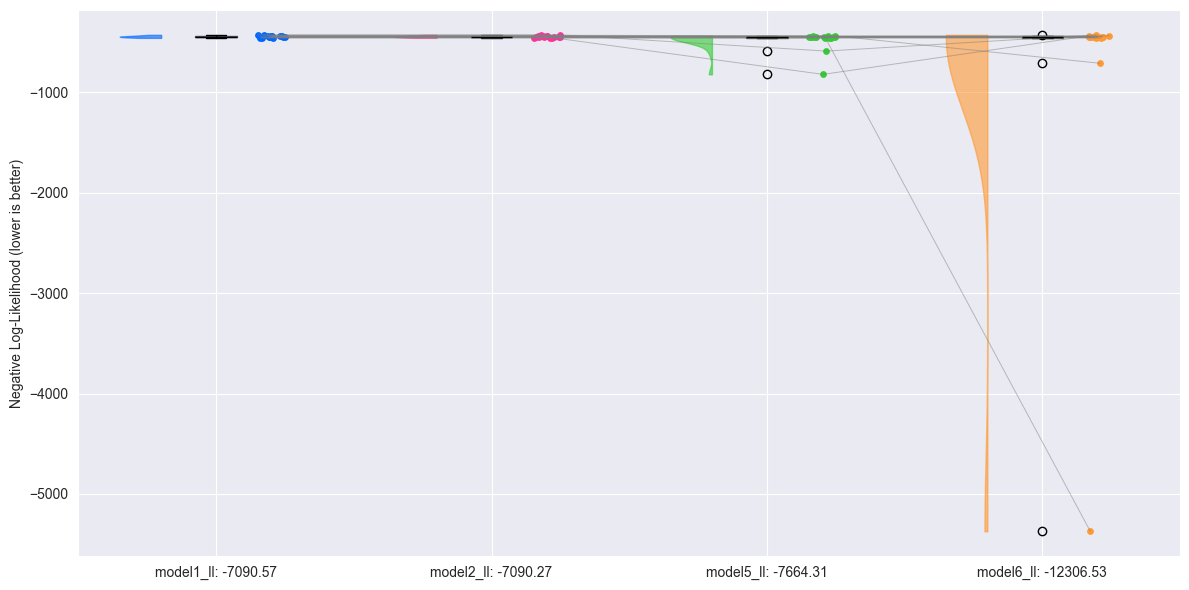

In [11]:
# Remove total column
model_fit_plot = model_fit_combined[model_fit_combined['subject'] != 'total']
model_fit_total = model_fit_combined[model_fit_combined['subject'] == 'total']

# Plot the two groups using a raincloud plot
utils.plotting_functions.paired_raincloud_4_groups(
    model_fit_plot,
    columns=['model1_ll', 'model2_ll', 'model5_ll','model6_ll'],
    labels=[f'model1_ll: {model_fit_total["model1_ll"].iloc[0]:.2f}', f'model2_ll: {model_fit_total["model2_ll"].iloc[0]:.2f}', f'model5_ll: {model_fit_total["model5_ll"].iloc[0]:.2f}', f'model6_ll: {model_fit_total["model6_ll"].iloc[0]:.2f}'],
    output_dir=output_dir,
    ylabel_name='Negative Log-Likelihood (lower is better)',
    plot_name='model_comparison_negative_log_likelihood'
)

In [12]:
# Print and save
print(model_fit_combined[['subject'] + [col for col in model_fit_combined.columns if 'll' in col]])
model_fit_combined.to_csv(f'{preprocessed_model_fit_folder}/model_fit_comparison.csv', index=False, sep=';')

   subject    model0_ll  model0_q_happy_pull  model0_q_angry_pull  \
0        5  -433.348327             0.275887            -0.208361   
1       10  -454.762216            -0.577491            -0.100027   
2       13  -432.921191            -0.459725             0.353081   
3       14  -447.990521             0.582061            -0.941072   
4       15  -455.832419             0.058720            -0.498713   
5       16  -435.258316             0.490192            -0.066470   
6       20  -442.557903            -0.496470             0.521986   
7       22  -448.521785             0.488354            -0.321955   
8       23  -443.911676             0.176643            -0.157567   
9       25  -440.610082            -0.254193            -0.703235   
10      27  -445.914774            -0.340361            -0.029773   
11      28  -445.981661             0.499965            -0.620115   
12      29  -428.537911             0.292606            -0.857859   
13      30  -439.515691           

In [13]:
# Prepare for Bayesian model selection
## Remove total row
model_fit_comparison = model_fit_combined.drop(model_fit_combined.tail(1).index,inplace=False)
## Extract AIC values into a matrix
aic_columns = [f'model{i}_AIC' for i in range(len(models))]
## Convert AIC to log model evidence
log_evidence_array = model_fit_comparison[aic_columns].values / -2

print(log_evidence_array)

[[ -439.34832699  -436.37010001  -438.34966196  -439.07092229
   -437.37010001  -439.95914179  -714.26583639]
 [ -460.76221614  -457.91071941  -459.87447912  -460.87447912
   -458.91071941  -460.22541877  -459.77067267]
 [ -438.92119124  -438.92968085  -440.89355301  -441.89355301
   -439.92968085  -448.90152433  -449.90181877]
 [ -453.99052139  -452.11869578  -454.11001245  -455.11001245
   -453.11869578  -453.68799509  -454.68811106]
 [ -461.83241914  -458.99493722  -460.98144858  -461.98144858
   -459.99493722  -460.71354732  -461.71361481]
 [ -441.25831604  -441.37285899  -443.36196437  -444.36196227
   -442.37285899  -823.75241077  -440.82295302]
 [ -448.55790305  -445.59825041  -447.57650827  -448.5765053
   -446.59825041  -447.76124558  -448.76132656]
 [ -454.52178508  -452.06890728  -454.05533351  -455.05533351
   -453.06890728  -454.58780079  -455.5879297 ]
 [ -449.91167574  -447.54475285  -449.5306156   -450.5306156
   -448.54475285  -449.00960588  -450.00968831]
 [ -446.6100

In [14]:
# Bayesian model selection
bms_result = utils.bayesian_model_selection.bms(log_evidence_array)
print(bms_result)
bms_result.to_csv(os.path.join(preprocessed_model_fit_folder, 'bayesian_model_fit.csv'), index=False, sep=';')

   alpha_post        xp       pxp          nfe       bor
0    1.159188  0.000020  0.000034 -7149.112246  0.000099
1   16.233212  0.999878  0.999793 -7149.112246  0.000099
2    1.085605  0.000019  0.000033 -7149.112246  0.000099
3    1.030167  0.000014  0.000028 -7149.112246  0.000099
4    1.301080  0.000037  0.000051 -7149.112246  0.000099
5    1.084494  0.000013  0.000027 -7149.112246  0.000099
6    1.106255  0.000019  0.000033 -7149.112246  0.000099


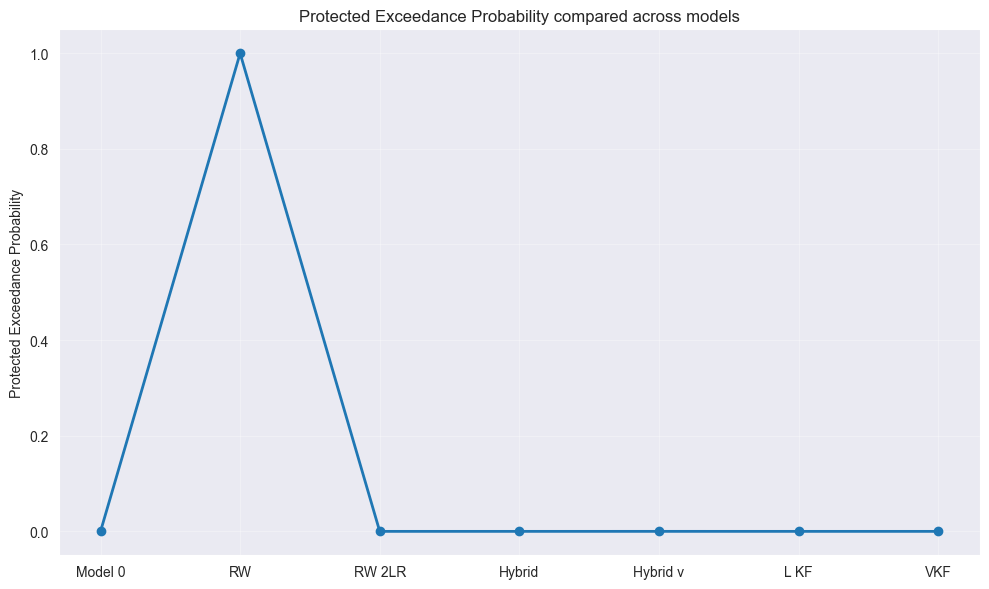

In [15]:
# Create the plot
plt.figure(figsize=(10, 6))

# Create x-axis positions
x_positions = range(len(bms_result))

only_plot_pxp = True

# Plot both lines
if only_plot_pxp:
    plt.plot(x_positions, bms_result['pxp'], marker='o', label='Protected Exceedance Probability', linewidth=2)
else:
    plt.plot(x_positions, bms_result['xp'], marker='o', label='Exceedance Probability', linewidth=2)
    plt.plot(x_positions, bms_result['pxp'], marker='o', label='Protected Exceedance Probability', linewidth=2)

# Set x-axis labels
x_labels = ['Model 0', 'RW', 'RW 2LR', 'Hybrid', 'Hybrid v', 'L KF', 'VKF'] #[f'Model {i}' for i in range(len(bms_result))]
plt.xticks(x_positions, x_labels)

# Add labels and title
if only_plot_pxp:
    plt.ylabel('Protected Exceedance Probability')
    plt.title('Protected Exceedance Probability compared across models')
else:
    plt.ylabel('(Protected) Exceedance Probability')
    plt.title('Exceedance Probability and Protected Exceedance Probability compared across models')
    plt.legend()
plt.grid(True, alpha=0.3)

# Display the plot
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'bayesian_model_comparison.pdf'))
plt.show()